In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -r "/content/drive/MyDrive/Zindi_Maize_Prediction_Challenge/requirements.txt"

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import timedelta
import os
import time
import datetime
import joblib
import os

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#modelling
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

#models
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from catboost import CatBoostRegressor, Pool

#data fetch
import ssl
import tempfile

import urllib.request
import requests

import warnings
warnings.filterwarnings('ignore')

In [4]:
start = time.time()

In [5]:
exp_code = str(round(time.time() * 1000))

In [6]:
MAIN_PATH = "/content/drive/MyDrive/Zindi_Maize_Prediction_Challenge/"
INPUT_DIR = MAIN_PATH + "data/"
OUTPUT_DIR = MAIN_PATH + "modelling_results/" + exp_code + "/"

In [7]:
# --- Paths
AGRIBORA_FULL_PATH = INPUT_DIR + "agriBORA_maize_prices.csv"
AGRIBORA_RECENT_PATH = INPUT_DIR + "agriBORA_maize_prices_weeks_46_to_51.csv"
KAMIS_PATH = INPUT_DIR + "kamis_maize_prices.csv"

#Target counties and commodity class
TARGET_COUNTIES = ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]
COMMODITY_CLASS = "Dry_White_Maize"

# --- Forecast targets (week start Mondays) ---
FORECAST_DATES = [
    pd.Timestamp("2025-12-22"),  # Week 52
    pd.Timestamp("2025-12-29"),  # ISO week 1 of 2026 (store as Week 1)
]

# Safe upper bound for direct horizons (because last observation can be earlier for some counties)
H_MAX = 8

# Fast backtest size
N_BACKTEST_CUTOFFS = 10

# Tuning controls
DO_TUNING = False
N_TRIALS_PER_MODEL = 5
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [8]:
#cleaning country column for consisitency
def norm_county(s):
    return s.strip() if isinstance(s, str) else s

In [9]:
def fetch_kamis_data():
    """
    Fetch latest KAMIS data from live API Excel export.
    Uses an unverified SSL context to handle certificate issues.
    """
    print("=" * 80)
    print("FETCHING LATEST KAMIS MAIZE PRICES")
    print("=" * 80)

    excel_url = "https://kamis.kilimo.go.ke/site/market?product=1&per_page=1500&export=excel"

    try:
        ssl_context = ssl._create_unverified_context()

        print("Downloading KAMIS Excel export ...")
        with tempfile.NamedTemporaryFile(mode="wb", suffix=".xlsx", delete=False) as tmp_file:
            tmp_path = tmp_file.name
            with urllib.request.urlopen(excel_url, context=ssl_context) as response:
                tmp_file.write(response.read())

        print("Reading Excel ...")
        df = pd.read_excel(tmp_path)

        os.unlink(tmp_path)
        print(f"Downloaded {len(df)} rows from KAMIS")
        return df

    except Exception as e:
        print("Error downloading KAMIS data:", e)
        return None

In [10]:
def preprocess_kamis_data(df):
    """
    Preprocess KAMIS data to match a standard schema.
    Uses fuzzy matching to locate key columns by name.
    """
    print("=" * 80)
    print("PREPROCESSING KAMIS DATA")
    print("=" * 80)

    if df is None or df.empty:
        print("[FAIL] Input dataframe is empty.")
        return None

    df_processed = df.copy()
    print(df_processed.head())
    df_processed.columns = df_processed.columns.str.replace(r"\s+", " ", regex=True).str.strip()

    # Identify columns
    column_mapping = {}
    for col in df_processed.columns:
        col_lower = str(col).lower()
        if "date" in col_lower:
            column_mapping["Date"] = col
        elif "county" in col_lower or "location" in col_lower:
            column_mapping["County"] = col
        elif "retail" in col_lower:
            column_mapping["Retail"] = col
        elif "wholesale" in col_lower:
            column_mapping["Wholesale"] = col
        elif "supply" in col_lower and "volume" in col_lower:
            column_mapping["SupplyVolume"] = col

    reversed_mapping = {v: k for k, v in column_mapping.items()}
    df_processed = df_processed.rename(columns=reversed_mapping)

    # Required columns
    for req in ["Date", "County"]:
        if req not in df_processed.columns:
            print(f"[FAIL] Required column missing: {req}")
            print("Columns found:", df_processed.columns.tolist())
            return None

    # Convert Date
    df_processed["Date"] = pd.to_datetime(df_processed["Date"], errors="coerce")
    df_processed = df_processed.dropna(subset=["Date"]).copy()

    df_processed["Year"] = df_processed["Date"].dt.year

    final_cols = ["Date", "County", "Year"]
    for col in ["Retail", "Wholesale", "SupplyVolume","Market","Commodity","Classification"]:
        if col in df_processed.columns:
            final_cols.append(col)
        else:
            print(f"[WARNING] Optional column missing: {col}")

    df_final = df_processed[final_cols].copy()

    # Convert numeric fields
    for col in ["Retail", "Wholesale", "SupplyVolume"]:
        if col in df_final.columns and not pd.api.types.is_numeric_dtype(df_final[col]):
            s = df_final[col].astype(str)
            s = s.str.replace(r"/Kg", "", regex=True)
            s = s.str.replace(r",", "", regex=True)
            s = s.str.replace(r"KES", "", regex=True)
            s = s.str.replace(r"Ksh", "", regex=True)
            s = s.str.replace("-", "", regex=False)
            s = s.str.strip()
            df_final[col] = pd.to_numeric(s, errors="coerce")

    df_final["Classification"] = (
    df_final["Classification"]
      .astype(str)
      .str.strip()
      .str.replace("-", "_", regex=False)
      .str.replace(" ", "_", regex=False)
    )

    # optional: collapse repeated underscores
    df_final["Classification"] = df_final["Classification"].str.replace(r"_+", "_", regex=True)


    # Drop rows where both Retail and Wholesale are missing (if both exist)
    if "Retail" in df_final.columns and "Wholesale" in df_final.columns:
        before = len(df_final)
        df_final = df_final.dropna(subset=["Retail", "Wholesale"], how="all").copy()
        print(f"Dropped {before - len(df_final)} rows with no Retail and no Wholesale prices.")

    if df_final.empty:
        print("No data left after preprocessing.")
        return None

    df_final = df_final.sort_values("Date").reset_index(drop=True)
    print("KAMIS preprocessing complete. Rows:", len(df_final))
    return df_final


In [11]:
def save_kamis_data(df, output_path=None):
    """
    Save preprocessed KAMIS data to CSV.
    """
    if output_path is None:
        output_path = os.path.join(INPUT_DIR, "kamis_maize_prices_downloaded.csv")

    df.to_csv(output_path, index=False)
    print("Saved KAMIS CSV:", output_path)
    print("Rows:", len(df))
    return output_path

In [12]:
kamis_path = os.path.join(INPUT_DIR, "kamis_maize_prices_downloaded.csv")
raw = fetch_kamis_data()
if raw is None or raw.empty:
    print("KAMIS fetch failed.")
else:
    processed = preprocess_kamis_data(raw)
    processed.columns = processed.columns.str.lower()
    save_kamis_data(processed, kamis_path)

FETCHING LATEST KAMIS MAIZE PRICES
Reading Excel ...
Downloaded 1500 rows from KAMIS
PREPROCESSING KAMIS DATA
   Commodity      Classification Grade Sex                      Market  \
0  Dry Maize         White Maize     -   -          Makutano Kirinyaga   
1  Dry Maize         White Maize     -   -                       Mulot   
2  Dry Maize        Yellow Maize     -   -                     Gikomba   
3  Dry Maize         White Maize     -   -                     Gikomba   
4  Dry Maize  Mixed-Traditional      -   -  Kitale Municipality Market   

  Wholesale     Retail  Supply Volume       County        Date  
0  50.00/Kg   60.00/Kg         2700.0    Kirinyaga  2026-02-11  
1  47.78/Kg   65.00/Kg        12000.0        Bomet  2026-02-11  
2  77.78/Kg  100.00/Kg            NaN      Nairobi  2026-02-11  
3  53.33/Kg   70.00/Kg            NaN      Nairobi  2026-02-11  
4  50.00/Kg   62.50/Kg          300.0  Trans-Nzoia  2026-02-11  
Dropped 0 rows with no Retail and no Wholesale prices.


In [13]:
processed.head()

,date,county,year,retail,wholesale,supplyvolume,market,commodity,classification
0,2025-06-20,Nairobi,2025,65.00,55.00,NaN,Kawangware,Dry Maize,White_Maize
1,2025-06-20,Kwale,2025,5000.00,3500.00,70000.0,Lungalunga,Dry Maize,Mixed_Traditional
2,2025-06-20,Bomet,2025,75.00,61.11,36000.0,Ndanai Market,Dry Maize,White_Maize
3,2025-06-20,Muranga,2025,60.00,NaN,NaN,Kirwara Market,Dry Maize,Mixed_Traditional
4,2025-06-20,Kakamega,2025,68.18,57.78,6300.0,Mumias,Dry Maize,White_Maize


In [14]:
print("KAMIS:", processed.shape, processed["date"].min().date(), "→", processed["date"].max().date())

KAMIS: (1500, 9) 2025-06-20 → 2026-02-11


# NASA POWER DATA

In [15]:
# Kenyan county centroid coordinates (approximate)
# Source: Public GIS datasets / government county shapefiles (preloaded here manually)
data = {
    "county_norm": [
        "Baringo", "Bomet", "Bungoma", "Busia", "Elgeyo-Marakwet", "Embu",
        "Garissa", "Homa Bay", "Isiolo", "Kajiado", "Kakamega", "Kericho",
        "Kiambu", "Kilifi", "Kirinyaga", "Kisii", "Kisumu", "Kitui",
        "Kwale", "Laikipia", "Lamu", "Machakos", "Makueni", "Mandera",
        "Marsabit", "Meru", "Migori", "Mombasa", "Murang'a", "Nairobi",
        "Nakuru", "Nandi", "Narok", "Nyamira", "Nyandarua", "Nyeri",
        "Samburu", "Siaya", "Taita-Taveta", "Tana River", "Tharaka-Nithi",
        "Trans Nzoia", "Turkana", "Uasin-Gishu", "Vihiga", "Wajir", "West Pokot"
    ],
    "latitude": [
        0.469, -0.801, 0.569, 0.434, 1.046, -0.531,
        -0.453, -0.495, 0.352, -2.098, 0.307, -0.377,
        -1.030, -3.510, -0.498, -0.681, -0.091, -1.366,
        -4.175, 0.421, -2.162, -1.517, -2.247, 3.937,
        3.544, 0.355, -1.064, -4.043, -0.783, -1.286,
        -0.303, 0.205, -1.145, -0.566, -0.258, -0.419,
        0.993, -0.133, -3.316, -1.845, -0.283, 1.010,
        3.118, 0.539, 0.023, 1.748, 1.532
    ],
    "longitude": [
        35.990, 35.342, 34.564, 34.124, 35.363, 37.456,
        39.654, 34.639, 38.570, 36.789, 34.751, 35.279,
        36.868, 39.800, 37.318, 34.778, 34.761, 38.015,
        39.458, 36.787, 40.902, 37.263, 37.892, 41.847,
        37.998, 37.655, 34.473, 39.668, 36.605, 36.816,
        36.188, 35.117, 35.860, 34.935, 36.574, 36.947,
        37.537, 34.266, 37.757, 39.507, 37.908, 35.021,
        35.587, 35.283, 34.729, 40.060, 35.162
    ]
}

centroids = pd.DataFrame(data)
centroids.head()

,county_norm,latitude,longitude
0,Baringo,0.469,35.990
1,Bomet,-0.801,35.342
2,Bungoma,0.569,34.564
3,Busia,0.434,34.124
4,Elgeyo-Marakwet,1.046,35.363


In [16]:
centroids = pd.DataFrame(data).copy()
centroids["county_key"] = centroids["county_norm"].apply(norm_county)

TARGET_COUNTIES = ["Kiambu","Kirinyaga","Mombasa","Nairobi","Uasin-Gishu"]
target_keys = [norm_county(x) for x in TARGET_COUNTIES]
centroids_target = centroids[centroids["county_key"].isin(target_keys)].copy()

centroids_target[["county_norm","latitude","longitude"]]

,county_norm,latitude,longitude
12,Kiambu,-1.030,36.868
14,Kirinyaga,-0.498,37.318
27,Mombasa,-4.043,39.668
29,Nairobi,-1.286,36.816
43,Uasin-Gishu,0.539,35.283


In [17]:
def fetch_power_daily_point(lat, lon, start_yyyymmdd, end_yyyymmdd,
                            parameters=None, community="AG", time_standard="UTC",
                            timeout=60):
    """
    Fetches daily meteorological data from the NASA POWER API for a single coordinate.

    This function queries the NASA Prediction Of Worldwide Energy Resources (POWER)
    API, standardizes the date index, and replaces the API's default missing value
    code (-999) with NaNs.

    Args:
        lat (float): Latitude of the point.
        lon (float): Longitude of the point.
        start_yyyymmdd (str): Start date in 'YYYYMMDD' format.
        end_yyyymmdd (str): End date in 'YYYYMMDD' format.
        parameters (list, optional): NASA POWER parameter keys. Defaults to
            precipitation, temperature (mean/max/min), wind speed, and solar radiation.
        community (str): The NASA community dataset (e.g., "AG" for Agriculture).
        time_standard (str): "UTC" or "LST" (Local Solar Time).
        timeout (int): Seconds to wait for the API response.

    Returns:
        pd.DataFrame: Daily time-series with columns for each parameter and a 'date' column.
    """
    if parameters is None:
        # Default keys: Precip, Mean Temp, Max Temp, Min Temp, Wind Speed, Solar Radiation
        parameters = ["PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN", "WS2M", "ALLSKY_SFC_SW_DWN"]

    base = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": ",".join(parameters),
        "community": community,
        "longitude": float(lon),
        "latitude": float(lat),
        "start": start_yyyymmdd,
        "end": end_yyyymmdd,
        "format": "JSON",
        "time-standard": time_standard,
    }

    r = requests.get(base, params=params, timeout=timeout)
    r.raise_for_status()
    js = r.json()

    # Extract the nested parameter data from the NASA JSON response
    param_dict = js["properties"]["parameter"]
    out = None
    for p, series in param_dict.items():
        s = pd.Series(series, name=p)
        s.index = pd.to_datetime(s.index, format="%Y%m%d")
        out = s.to_frame() if out is None else out.join(s, how="outer")

    # NASA uses -999 for missing/null data
    out = out.replace(-999, np.nan).sort_index()
    out.index.name = "date"
    return out.reset_index()

In [18]:
def power_daily_to_weekly(df_daily):
    """
    Aggregates daily NASA POWER data into weekly summaries.

    Uses specific aggregation logic for different metrics:
    - Summation for precipitation (total rainfall per week).
    - Mean/Min/Max for temperatures and wind.
    - Mean for solar radiation.

    Args:
        df_daily (pd.DataFrame): Daily data from fetch_power_daily_point.

    Returns:
        pd.DataFrame: Weekly aggregated data with 'date' representing the
            Monday of each week.
    """
    d = df_daily.copy()
    # Normalize date to the preceding Monday
    d["week_start"] = d["date"] - pd.to_timedelta(d["date"].dt.weekday, unit="D")

    # Define aggregation map based on existing columns
    agg = {}
    if "PRECTOTCORR" in d.columns:
        agg["power_precip_mm_sum"] = ("PRECTOTCORR", "sum")
    if "T2M" in d.columns:
        agg["power_t2m_c_mean"] = ("T2M", "mean")
    if "T2M_MAX" in d.columns:
        agg["power_t2m_c_max"] = ("T2M_MAX", "max")
    if "T2M_MIN" in d.columns:
        agg["power_t2m_c_min"] = ("T2M_MIN", "min")
    if "WS2M" in d.columns:
        agg["power_ws2m_mean"] = ("WS2M", "mean")
    if "ALLSKY_SFC_SW_DWN" in d.columns:
        agg["power_srad_mean"] = ("ALLSKY_SFC_SW_DWN", "mean")

    w = (d.groupby("week_start", as_index=False)
            .agg(**agg)
            .rename(columns={"week_start": "date"}))
    return w


In [19]:
def fetch_power_weekly_for_counties(centroids_df, start_date, end_date,
                                    sleep_s=0.25, parameters=None):
    """
    Iterates through multiple counties to fetch and aggregate weather data.

    This is a wrapper that manages API rate-limiting by sleeping between
    requests and normalizes county naming conventions for consistent joining.

    Args:
        centroids_df (pd.DataFrame): DataFrame containing 'county_norm',
            'latitude', and 'longitude' for each region.
        start_date (str/datetime): Start of the collection period.
        end_date (str/datetime): End of the collection period.
        sleep_s (float): Delay in seconds between API calls to avoid rate-limiting.
        parameters (list, optional): Specific NASA POWER parameters to fetch.

    Returns:
        pd.DataFrame: A long-format panel dataset containing weekly weather
            features for all requested counties.
    """
    start = pd.Timestamp(start_date).strftime("%Y%m%d")
    end   = pd.Timestamp(end_date).strftime("%Y%m%d")

    rows = []
    for _, r in centroids_df.iterrows():
        county = r["county_norm"]
        lat, lon = r["latitude"], r["longitude"]

        # Fetch daily, then convert to weekly
        daily = fetch_power_daily_point(lat, lon, start, end, parameters=parameters)
        weekly = power_daily_to_weekly(daily)

        weekly["county_norm"] = county
        rows.append(weekly)

        # delay for NASA API
        time.sleep(sleep_s)

    out = pd.concat(rows, ignore_index=True)

    # Standardize county names using the helper norm_county
    out["county_key"] = out["county_norm"].apply(norm_county)
    out = out.drop(columns=["county_norm"]).rename(columns={"county_key": "county"})

    return out

In [20]:
power_weekly = fetch_power_weekly_for_counties(
    centroids_target,
    start_date="2021-05-24",
    end_date="2025-12-29",   # include forecast horizon, however note we'll use LAGS only
)

power_weekly.head()

,date,power_precip_mm_sum,power_t2m_c_mean,power_t2m_c_max,power_t2m_c_min,power_ws2m_mean,power_srad_mean,county
0,2021-05-24,8.52,17.905714,25.56,12.37,2.368571,17.701429,Kiambu
1,2021-05-31,0.53,17.951429,26.17,12.39,2.407143,18.757143,Kiambu
2,2021-06-07,0.88,18.085714,26.82,11.48,2.177143,16.798571,Kiambu
3,2021-06-14,0.90,17.881429,26.02,12.45,2.170000,15.610000,Kiambu
4,2021-06-21,4.18,17.020000,25.72,10.95,2.241429,15.898571,Kiambu


# READING PROVIDED DATA

## AGRIBORA

In [21]:
#update agri_data
ag_full = pd.read_csv(AGRIBORA_FULL_PATH)
ag_recent = pd.read_csv(AGRIBORA_RECENT_PATH)
ag_full["Date"] = pd.to_datetime(ag_full["Date"])
ag_recent["Date"] = pd.to_datetime(ag_recent["Date"])

#combine witht the recent data
ag_full = ag_full[(ag_full["Commodity_Classification"] == COMMODITY_CLASS) & (ag_full["County"].isin(TARGET_COUNTIES))].copy()
ag_recent = ag_recent[(ag_recent["Commodity_Classification"] == COMMODITY_CLASS) & (ag_recent["County"].isin(TARGET_COUNTIES))].copy()

ag = pd.concat([ag_full, ag_recent], ignore_index=True)
ag = ag.sort_values(["County","Date"]).drop_duplicates(["County","Date"], keep="last").reset_index(drop=True)
ag.columns = ag.columns.str.lower()

ag["county"] = ag["county"].apply(norm_county)

## LOAD CLEANED KAMIS DATA

In [22]:
#load kamis
kamis = pd.read_csv(KAMIS_PATH)
kamis["Date"] = pd.to_datetime(kamis["Date"])
kamis.columns = kamis.columns.str.lower()

In [23]:
cols = ['classification','county','date','retail','wholesale','supplyvolume']
kamis1 = kamis[cols]
processed1=processed[cols]

In [24]:
kamis_updated = pd.concat([kamis1,processed1],axis=0)
#use only white maize
kamis_white = kamis_updated[kamis_updated["classification"] == "White_Maize"].copy()

kamis_white.shape

(15793, 6)

In [25]:
#drop duplicates
kamis_white = kamis_white.drop_duplicates()
kamis_white.shape

(15003, 6)

In [26]:
print("AgriBORA:", ag.shape, ag["date"].min().date(), "→", ag["date"].max().date())
print("KAMIS:", kamis_white.shape, kamis_white["date"].min().date(), "→", kamis_white["date"].max().date())

AgriBORA: (232, 6) 2023-10-02 → 2025-12-15
KAMIS: (15003, 6) 2021-05-24 → 2026-02-11


# CREATE DATA GRID

In [27]:
def iso_year_week_from_date(dts: pd.Series) -> pd.DataFrame:
    """
    Extracts ISO year and week components from a series of dates.

    Args:
        dts (pd.Series): A pandas Series of datetime objects.

    Returns:
        pd.DataFrame: A DataFrame containing 'iso_year', 'iso_week',
            and a formatted 'Year_Week' string (e.g., "2023-01").
    """
    iso = dts.dt.isocalendar()
    out = pd.DataFrame({
        "iso_year": iso["year"].astype(int),
        "iso_week": iso["week"].astype(int)
    })
    out["Year_Week"] = out["iso_year"].astype(str) + "-" + out["iso_week"].astype(str).str.zfill(2)
    return out

In [28]:
def make_weekly_grid(counties, start_date, end_date):
    """
    Creates a Cartesian product grid of counties and weekly dates.

    Normalizes the start and end dates to the nearest preceding Monday to
    ensure consistent weekly alignment.

    Args:
        counties (list): List of unique county identifiers.
        start_date (str or datetime): The beginning of the time range.
        end_date (str or datetime): The end of the time range.

    Returns:
        pd.DataFrame: A long-format DataFrame with 'county', 'date',
            and ISO calendar features.
    """
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    # Snap to the most recent Monday
    start = start - pd.to_timedelta(start.weekday(), unit="D")
    end = end - pd.to_timedelta(end.weekday(), unit="D")

    weeks = pd.date_range(start=start, end=end, freq="W-MON")
    grid = pd.MultiIndex.from_product([counties, weeks], names=["county","date"]).to_frame(index=False)

    iso = iso_year_week_from_date(grid["date"])
    grid = pd.concat([grid, iso], axis=1)
    return grid

# ADD FEATURES

In [29]:
def add_calendar_features(df):
    """
    Adds cyclical time features and holiday-season flags.

    Uses sine/cosine transformations for 'iso_week' to ensure the model
    understands that week 52 and week 1 are temporally close.

    Args:
        df (pd.DataFrame): DataFrame containing an 'iso_week' column.

    Returns:
        pd.DataFrame: The DataFrame with 'week_sin', 'week_cos', and 'is_year_end' added.
    """
    w = df["iso_week"].astype(float)
    df["week_sin"] = np.sin(2 * np.pi * w / 52.0)
    df["week_cos"] = np.cos(2 * np.pi * w / 52.0)
    df["is_year_end"] = (df["iso_week"] >= 48).astype(int)
    return df

In [30]:
def add_gap_aware_features(df, value_col="wholesale", group_col="county", date_col="date", prefix="ag"):
    """
    Generates time-series features that account for missing observations (gaps).

    This function calculates the 'last known value' (forward-filled), the time
    since that observation, and various lags/moving averages based on that
    last known state.

    Args:
        df (pd.DataFrame): The input panel data.
        value_col (str): The column name to calculate features for.
        group_col (str): The column to group by (e.g., 'county').
        date_col (str): The datetime column.
        prefix (str): Prefix for the newly created feature columns.

    Returns:
        pd.DataFrame: DataFrame with lags, momentum, and rolling mean features.
    """
    df = df.sort_values([group_col, date_col]).copy()
    x = df[value_col]

    # Identify the date of the last non-null observation for gap calculation
    last_obs_date = df[date_col].where(x.notna()).groupby(df[group_col]).ffill()
    df[f"{prefix}_last"] = x.groupby(df[group_col]).ffill()

    # Calculate weeks since the last observation
    gap = ((df[date_col] - last_obs_date).dt.days / 7.0)
    df[f"{prefix}_gap_weeks"] = gap.fillna(52).clip(0, 52)

    # Generate standard lags
    for lag in [1, 2, 3, 4, 8, 12]:
        df[f"{prefix}_lag{lag}"] = df.groupby(group_col)[f"{prefix}_last"].shift(lag)

    # Momentum features (change over time)
    df[f"{prefix}_mom1"] = df[f"{prefix}_lag1"] - df[f"{prefix}_lag2"]
    df[f"{prefix}_mom4"] = df[f"{prefix}_lag1"] - df[f"{prefix}_lag4"]

    # Rolling window averages
    for win in [4, 8, 12]:
        df[f"{prefix}_roll{win}_mean"] = (
            df.groupby(group_col)[f"{prefix}_last"]
              .shift(1)
              .rolling(win, min_periods=1)
              .mean()
              .reset_index(level=0, drop=True)
        )
    return df

In [31]:
def build_ag_panel(ag_df, extend_weeks=0):
    """
    Constructs a complete panel dataset for forecasting.

    Combines grid generation, calendar features, and gap-aware time-series
    features. It also calculates cross-sectional (national) statistics.

    Args:
        ag_df (pd.DataFrame): Raw agricultural data with county and date.
        extend_weeks (int): Number of future weeks to extend the grid beyond
            the maximum available date.

    Returns:
        pd.DataFrame: A fully featured panel ready for model training or inference.
    """
    start_date = ag_df["date"].min()
    # Ensure the grid covers the provided data, forecast targets, and any requested extension
    end_date = max(ag_df["date"].max(), max(FORECAST_DATES)) + pd.to_timedelta(7 * extend_weeks, unit="D")

    grid = make_weekly_grid(TARGET_COUNTIES, start_date, end_date)

    # Merge actuals onto the grid
    panel = grid.merge(ag_df[["county", "date", "wholesale"]], on=["county", "date"], how="left")

    # Feature Engineering Pipeline
    panel = add_calendar_features(panel)
    panel = add_gap_aware_features(panel, value_col="wholesale", prefix="ag")

    # Cross-sectional features (National Trends)
    panel["ag_national_last_mean"] = panel.groupby("date")["ag_last"].transform("mean")
    panel["ag_national_last_std"] = panel.groupby("date")["ag_last"].transform("std")

    return panel

        county  weeks_observed  weeks_possible  coverage
2      Mombasa              23             126  0.182540
1    Kirinyaga              31             126  0.246032
0       Kiambu              36             126  0.285714
3      Nairobi              62             126  0.492063
4  Uasin-Gishu              80             126  0.634921


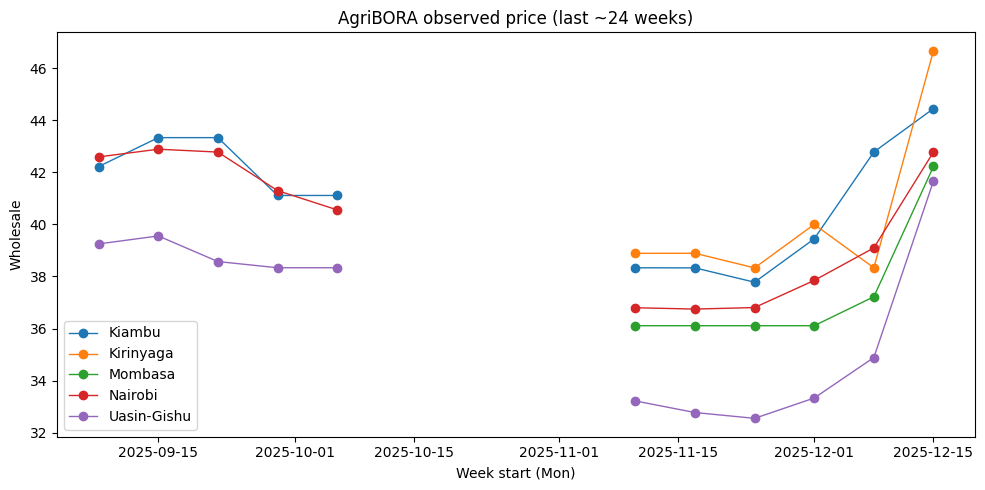

In [32]:
#Agribora coverage plot
panel = build_ag_panel(ag, extend_weeks=H_MAX)

coverage = panel.groupby("county", as_index=False).agg(weeks_observed=("wholesale", lambda s: int(s.notna().sum())))
coverage["weeks_possible"] = panel["date"].nunique()
coverage["coverage"] = coverage["weeks_observed"] / coverage["weeks_possible"]
print(coverage.sort_values("coverage"))

# plot
recent = panel[panel["date"] >= (panel["date"].max() - pd.Timedelta(days=7*24))].copy()
plt.figure(figsize=(10,5))
for c in TARGET_COUNTIES:
    s = recent[recent["county"]==c].sort_values("date")
    plt.plot(s["date"], s["wholesale"], marker="o", linewidth=1, label=c)
plt.title("AgriBORA observed price (last ~24 weeks)")
plt.xlabel("Week start (Mon)")
plt.ylabel("Wholesale")
plt.legend()
plt.tight_layout()
plt.show()

        county  weeks_observed  weeks_possible  coverage
2      Mombasa              22             255  0.086275
0       Kiambu              35             255  0.137255
4  Uasin-Gishu             196             255  0.768627
1    Kirinyaga             294             255  1.152941
3      Nairobi             316             255  1.239216


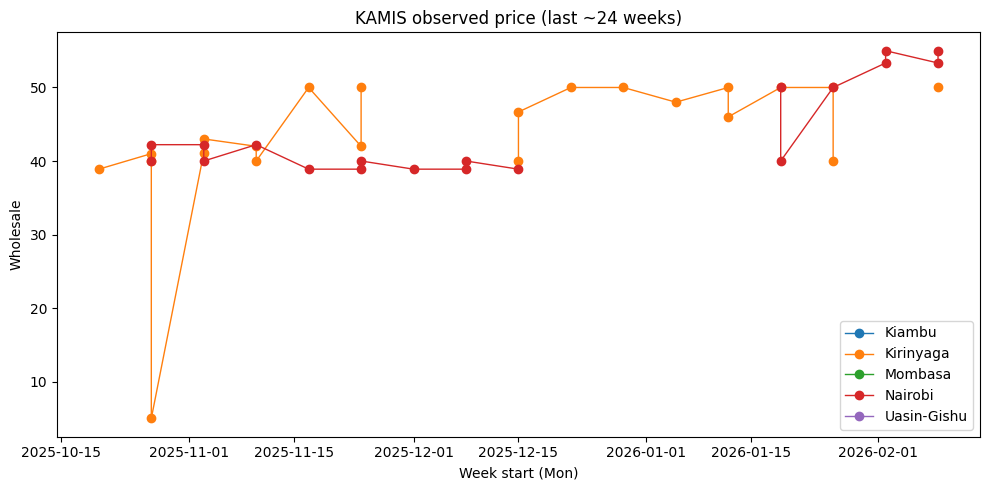

In [33]:
#kamis coverage plot
kamis_panel = build_ag_panel(kamis_white, extend_weeks=H_MAX)

kamis_coverage = kamis_panel.groupby("county", as_index=False).agg(weeks_observed=("wholesale", lambda s: int(s.notna().sum())))
kamis_coverage["weeks_possible"] = kamis_panel["date"].nunique()
kamis_coverage["coverage"] = kamis_coverage["weeks_observed"] / kamis_coverage["weeks_possible"]
print(kamis_coverage.sort_values("coverage"))

# Recent plot
recent = kamis_panel[kamis_panel["date"] >= (kamis_panel["date"].max() - pd.Timedelta(days=7*24))].copy()
plt.figure(figsize=(10,5))
for c in TARGET_COUNTIES:
    s = recent[recent["county"]==c].sort_values("date")
    plt.plot(s["date"], s["wholesale"], marker="o", linewidth=1, label=c)
plt.title("KAMIS observed price (last ~24 weeks)")
plt.xlabel("Week start (Mon)")
plt.ylabel("Wholesale")
plt.legend()
plt.tight_layout()
plt.show()

# KAMIS AGGREGATIONS

In [34]:
def clip_outliers_by_county(df: pd.DataFrame,
                           value_col: str = "wholesale",
                           lo_q: float = 0.01,
                           hi_q: float = 0.99) -> pd.DataFrame:
    """
    Clips values in a column based on county-specific quantiles.

    This prevents extreme price outliers in one county from affecting
    the global distribution while respecting that different counties
    may have different price floors and ceilings.

    Args:
        df (pd.DataFrame): The input DataFrame containing a 'county' column.
        value_col (str): The name of the numerical column to clip.
        lo_q (float): The lower quantile threshold (0.0 to 1.0).
        hi_q (float): The upper quantile threshold (0.0 to 1.0).

    Returns:
        pd.DataFrame: The DataFrame with 'value_col' values capped within
            the specified quantile range.
    """
    d = df.copy()
    # Calculate thresholds per county
    qs = d.groupby("county")[value_col].quantile([lo_q, hi_q]).unstack()
    qs.columns = ["lo", "hi"]

    # Map thresholds back to the main dataframe
    d = d.join(qs, on="county")
    d[value_col] = d[value_col].clip(d["lo"], d["hi"])

    return d.drop(columns=["lo", "hi"])

In [35]:
def kamis_weekly_agg(kamis_norm: pd.DataFrame,
                     counties: list[str],
                     clip_outliers: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Aggregates normalized KAMIS data to weekly county-level and national-level summaries.

    The function filters for specific counties, optionally handles outliers,
    and produces two levels of granularity. It uses the median for price
    columns to remain robust against noise and the sum for volume.

    Args:
        kamis_norm (pd.DataFrame): Normalized KAMIS market data.
        counties (list[str]): List of counties to include in the aggregation.
            If None, all counties in the dataset are used.
        clip_outliers (bool): Whether to apply quantile clipping to the
            wholesale prices before aggregating.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame]: A pair of (national_df, county_df).
            - national_df: Weekly medians/sums across all selected counties.
            - county_df: Weekly medians/sums per specific county.
    """
    k = kamis_norm.copy()

    # Filter by county list
    if counties is not None:
        k = k[k["county"].isin(counties)].copy()

    # Apply outlier mitigation
    if clip_outliers and "wholesale" in k.columns:
        k = clip_outliers_by_county(k, "wholesale")

    # Aggregate by County and Date
    #Median is used for prices (wh/rt) to avoid skewness from outliers
    k_cnty = (k.groupby(["county", "date"], as_index=False)
               .agg(k_wh=("wholesale", "median"),
                    k_rt=("retail", "median"),
                    k_supply=("supplyvolume", "sum"))
               .sort_values(["county", "date"]))

    # Aggregate by Date only (National Trend)
    k_nat = (k.groupby("date", as_index=False)
              .agg(k_nat_wh=("wholesale", "median"),
                   k_nat_rt=("retail", "median"),
                   k_nat_supply=("supplyvolume", "sum"))
              .sort_values("date"))

    return k_nat, k_cnty

In [36]:
def add_kamis_lags(k_nat: pd.DataFrame, k_cnty: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Creates one-week lagged features for both national and county-level KAMIS data.

    This function shifts price and supply metrics forward by one period to prevent
    look-ahead bias.

    Args:
        k_nat (pd.DataFrame): Weekly national-level aggregated data.
            Expected columns: ['date', 'k_nat_wh', 'k_nat_rt', 'k_nat_supply'].
        k_cnty (pd.DataFrame): Weekly county-level aggregated data.
            Expected columns: ['county', 'date', 'k_wh', 'k_rt', 'k_supply'].

    Returns:
        tuple[pd.DataFrame, pd.DataFrame]: A pair of (nat_lags, cnty_lags).
            - nat_lags: National data containing only the 'date' and 1-week lagged features.
            - cnty_lags: County data containing 'county', 'date', and 1-week lagged features.
    """
    # Process National Lags
    nat = k_nat.sort_values("date").copy()
    for c in ["k_nat_wh", "k_nat_rt", "k_nat_supply"]:
        # Shift(1) moves the previous week's value to the current row's index
        nat[c + "_lag1"] = nat[c].shift(1)

    # Process County Lags
    cnty = k_cnty.sort_values(["county", "date"]).copy()
    for c in ["k_wh", "k_rt", "k_supply"]:
        # Groupby 'county' ensures lags don't bleed between different geographical areas
        cnty[c + "_lag1"] = cnty.groupby("county")[c].shift(1)

    # Filter to return only the join keys and the lagged features
    nat = nat[["date", "k_nat_wh_lag1", "k_nat_rt_lag1", "k_nat_supply_lag1"]]
    cnty = cnty[["county", "date", "k_wh_lag1", "k_rt_lag1", "k_supply_lag1"]]

    return nat, cnty

# AGRIBORA AGGREGATIONS

In [37]:
def normalize_agri(ag_raw: pd.DataFrame, counties: list[str]) -> pd.DataFrame:
    """
    Standardizes raw agricultural data for time-series analysis.

    This function performs column renaming, date normalization (snapping to
    Mondays), filtering for target counties, and ensures numerical types.
    It handles duplicates by averaging values within the same county-week.

    Args:
        ag_raw (pd.DataFrame): The raw input data containing at least
            'date', 'county', and 'wholesale' columns.
        counties (list[str]): List of valid county names to retain.

    Returns:
        pd.DataFrame: A cleaned DataFrame with unique (county, date) pairs
            and standardized weekly dates.
    """
    a = ag_raw.copy()
    a.columns = [c.lower() for c in a.columns]

    # Standardize dates to the start of the week (Monday)
    a["date"] = pd.to_datetime(a["date"])
    a["date"] = a["date"] - pd.to_timedelta(a["date"].dt.weekday, unit="D")

    # Filter for relevant geography and ensure price is numeric
    a = a[a["county"].isin(counties)].copy()
    a["wholesale"] = pd.to_numeric(a["wholesale"], errors="coerce")

    # Deduplicate: if multiple prices exist for one week, take the mean
    a = (a.groupby(["county", "date"], as_index=False)["wholesale"].mean()
           .sort_values(["county", "date"]))
    return a

In [38]:
def add_prev_observed_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates velocity and temporal features based on previous observations.

    This function calculates the 'slope' (price change
    per week) which accounts for irregular time intervals (gaps) between
    reporting dates. It also adds cyclical calendar features.

    Args:
        df (pd.DataFrame): A DataFrame containing 'county', 'date', and
            'wholesale' price.

    Returns:
        pd.DataFrame: The DataFrame augmented with:
            - prev_price/date: Values from the last 2 observations.
            - gap_weeks: Number of weeks since previous observations.
            - slope1: The rate of price change (Price_Delta / Time_Delta).
            - wk_sin/cos: Cyclical week-of-year encodings.
    """
    d = df.sort_values(["county", "date"]).copy()

    # Shift to get the 1st and 2nd previous observations
    d["prev_date"]  = d.groupby("county")["date"].shift(1)
    d["prev_price"] = d.groupby("county")["wholesale"].shift(1)
    d["prev2_date"]  = d.groupby("county")["date"].shift(2)
    d["prev2_price"] = d.groupby("county")["wholesale"].shift(2)

    # Calculate temporal distance in weeks
    d["gap1_weeks"] = (d["date"] - d["prev_date"]).dt.days / 7.0
    d["gap2_weeks"] = (d["date"] - d["prev2_date"]).dt.days / 7.0

    # Calculate price velocity (slope)
    # Using slope instead of simple delta helps normalize for missing data weeks
    d["slope1"] = (d["wholesale"] - d["prev_price"]) / d["gap1_weeks"]
    d["slope1"] = d["slope1"].replace([np.inf, -np.inf], np.nan)

    # Cyclical Calendar Features
    iso = d["date"].dt.isocalendar()
    d["iso_week"] = iso.week.astype(int)
    d["wk_sin"] = np.sin(2 * np.pi * d["iso_week"] / 52.0)
    d["wk_cos"] = np.cos(2 * np.pi * d["iso_week"] / 52.0)
    d["is_year_end"] = (d["iso_week"] >= 48).astype(int)

    return d

# MERGE AGRIDATA AND KAMIS DATA

In [39]:
def merge_kamis_features(ag_feat: pd.DataFrame,
                         k_nat_lag: pd.DataFrame,
                         k_cnty_lag: pd.DataFrame) -> pd.DataFrame:
    """
    Merges lagged national and county-level KAMIS data with a fallback strategy.

    This function combines agricultural features with market data. It implements
    a hierarchical fill: if a specific county's lagged data is missing, it
    defaults to the national average for that same week to ensure the model
    still has a baseline signal.

    Args:
        ag_feat (pd.DataFrame): The primary agricultural feature panel.
        k_nat_lag (pd.DataFrame): Lagged national-level market features.
        k_cnty_lag (pd.DataFrame): Lagged county-level market features.

    Returns:
        pd.DataFrame: The merged DataFrame with filled market features and
            no remaining NaNs in the KAMIS columns.
    """
    d = ag_feat.copy()

    # Merge external market data
    d = d.merge(k_nat_lag, on="date", how="left")
    d = d.merge(k_cnty_lag, on=["county", "date"], how="left")

    # Fallback strategy: If county-specific lag is NaN, use national lag
    d["k_wh_lag1"] = d["k_wh_lag1"].fillna(d["k_nat_wh_lag1"])
    d["k_supply_lag1"] = d["k_supply_lag1"].fillna(d["k_nat_supply_lag1"])
    d["k_rt_lag1"] = d["k_rt_lag1"].fillna(d["k_nat_rt_lag1"])

    # Final cleanup: fill any remaining gaps (e.g., start of series) with 0.0
    cols_to_fill = [
        "k_nat_wh_lag1", "k_nat_supply_lag1", "k_nat_rt_lag1",
        "k_wh_lag1", "k_supply_lag1", "k_rt_lag1"
    ]
    for c in cols_to_fill:
        d[c] = d[c].fillna(0.0)

    return d

In [40]:
def make_supervised_delta(df_feat: pd.DataFrame, h: int) -> pd.DataFrame:
    """
    Transforms the panel into a supervised learning task to predict price change.

    Instead of predicting the absolute price, this creates a target variable
    representing the 'delta' (change) between the current price and the price
    'h' weeks into the future.

    Args:
        df_feat (pd.DataFrame): The feature-engineered panel data.
        h (int): The forecast horizon in weeks.

    Returns:
        pd.DataFrame: A DataFrame containing the feature set and a new
            'delta_h{h}' column. Rows where either the current or future
            wholesale price is missing are dropped.
    """
    d = df_feat.copy()

    # Calculate the timestamp for the future target
    d["target_date"] = d["date"] + pd.Timedelta(days=7 * h)

    # Prepare the future values for merging back as the ground truth
    future = d[["county", "date", "wholesale"]].rename(
        columns={"date": "target_date", "wholesale": "y_future"}
    )

    # Align current features with future prices
    d = d.merge(future, on=["county", "target_date"], how="left")

    # Remove rows where we don't have a valid starting point or a target result
    d = d.dropna(subset=["wholesale", "y_future"])

    # Calculate the supervised target: price change over 'h' weeks
    d[f"delta_h{h}"] = d["y_future"] - d["wholesale"]

    return d

In [41]:
# normalize agribora
ag_n = normalize_agri(ag, TARGET_COUNTIES)

# aggregate kamis weekly + lag
k_nat, k_cnty = kamis_weekly_agg(kamis_white, counties=None, clip_outliers=True)
k_nat_lag, k_cnty_lag = add_kamis_lags(k_nat, k_cnty)

# make agri features + merge kamis
ag_feat = add_prev_observed_features(ag_n)
ag_feat = merge_kamis_features(ag_feat, k_nat_lag, k_cnty_lag)


ag_feat["county"] = ag_feat["county"].apply(norm_county)

# merge NASA POWER (county-week)
ag_feat = ag_feat.merge(
    power_weekly,
    on=["county","date"],
    how="left"
)

In [42]:
def add_lags(df, cols, group_col=None, lags=(1,2,4,8)):
    out = df.copy()
    if group_col is None:
        for c in cols:
            for L in lags:
                out[f"{c}_lag{L}"] = out[c].shift(L)
    else:
        for c in cols:
            for L in lags:
                out[f"{c}_lag{L}"] = out.groupby(group_col)[c].shift(L)
    return out

In [43]:
# create LAGGED exogenous features only
power_cols = [c for c in ag_feat.columns if c.startswith("power_")]
ag_feat = add_lags(ag_feat, power_cols, group_col="county", lags=(1,2,4,8))

In [44]:
print(ag_feat.columns)

Index(['county', 'date', 'wholesale', 'prev_date', 'prev_price', 'prev2_date',
       'prev2_price', 'gap1_weeks', 'gap2_weeks', 'slope1', 'iso_week',
       'wk_sin', 'wk_cos', 'is_year_end', 'k_nat_wh_lag1', 'k_nat_rt_lag1',
       'k_nat_supply_lag1', 'k_wh_lag1', 'k_rt_lag1', 'k_supply_lag1',
       'power_precip_mm_sum', 'power_t2m_c_mean', 'power_t2m_c_max',
       'power_t2m_c_min', 'power_ws2m_mean', 'power_srad_mean',
       'power_precip_mm_sum_lag1', 'power_precip_mm_sum_lag2',
       'power_precip_mm_sum_lag4', 'power_precip_mm_sum_lag8',
       'power_t2m_c_mean_lag1', 'power_t2m_c_mean_lag2',
       'power_t2m_c_mean_lag4', 'power_t2m_c_mean_lag8',
       'power_t2m_c_max_lag1', 'power_t2m_c_max_lag2', 'power_t2m_c_max_lag4',
       'power_t2m_c_max_lag8', 'power_t2m_c_min_lag1', 'power_t2m_c_min_lag2',
       'power_t2m_c_min_lag4', 'power_t2m_c_min_lag8', 'power_ws2m_mean_lag1',
       'power_ws2m_mean_lag2', 'power_ws2m_mean_lag4', 'power_ws2m_mean_lag8',
       'power

In [45]:
ag_feat.to_csv(INPUT_DIR + "processed_data.csv",index=False)

# MODELLING

In [46]:
def rmse(y_true, y_pred):
    """
    Calculates the Root Mean Squared Error.

    RMSE penalizes larger errors more heavily than MAE, making it useful
    when large price deviations are particularly costly.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    """
    Calculates the Mean Absolute Error.

    MAE provides a linear score that represents the average expected
    error in the same units as the price.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

In [47]:
def get_default_feature_spec(df):
    """
    Identifies available features from a predefined list of high-value predictors.

    This ensures that the model only attempts to use columns that exist in the
    current dataset, maintaining stability between training and inference.

    Args:
        df (pd.DataFrame): The dataset to check for feature columns.

    Returns:
        tuple[list, list]: (categorical_columns, numerical_columns)
    """
    preferred_num = [
        # agriBORA features
        "wholesale","prev_price","prev2_price","gap1_weeks","gap2_weeks","slope1",
        "iso_week","wk_sin","wk_cos","is_year_end",

        # KAMIS lag features (national + county fallback)
        "k_nat_wh_lag1","k_nat_supply_lag1","k_nat_rt_lag1",
        "k_wh_lag1","k_supply_lag1","k_rt_lag1"

        #precip
#         'power_precip_mm_sum', 'power_t2m_c_mean', 'power_t2m_c_max',
#        'power_t2m_c_min', 'power_ws2m_mean', 'power_srad_mean',
#        'power_precip_mm_sum_lag1', 'power_precip_mm_sum_lag2',
#        'power_precip_mm_sum_lag4', 'power_precip_mm_sum_lag8',
#        'power_t2m_c_mean_lag1', 'power_t2m_c_mean_lag2',
#        'power_t2m_c_mean_lag4', 'power_t2m_c_mean_lag8',
#        'power_t2m_c_max_lag1', 'power_t2m_c_max_lag2', 'power_t2m_c_max_lag4',
#        'power_t2m_c_max_lag8', 'power_t2m_c_min_lag1', 'power_t2m_c_min_lag2',
#        'power_t2m_c_min_lag4', 'power_t2m_c_min_lag8', 'power_ws2m_mean_lag1',
#        'power_ws2m_mean_lag2', 'power_ws2m_mean_lag4', 'power_ws2m_mean_lag8',
#        'power_srad_mean_lag1', 'power_srad_mean_lag2', 'power_srad_mean_lag4',
#        'power_srad_mean_lag8'
    ]
    cat_cols = ["county"]
    num_cols = [c for c in preferred_num if c in df.columns]
    cat_cols = [c for c in cat_cols if c in df.columns]
    return cat_cols, num_cols

In [48]:
def build_sklearn_preprocessor(cat_cols, num_cols, scale_numeric=False):
    """
    Constructs a Scikit-Learn ColumnTransformer for automated data cleaning.

    Handles missing values via median/mode imputation and encodes categorical
    variables. Optionally scales numerical data for models like Ridge or MLP.

    Args:
        cat_cols (list): List of categorical feature names.
        num_cols (list): List of numerical feature names.
        scale_numeric (bool): Whether to apply StandardScaler to numerical features.

    Returns:
        ColumnTransformer: A fitted-ready preprocessing object.
    """
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    numeric = Pipeline(steps=num_steps)
    categorical = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric, num_cols),
            ("cat", categorical, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

In [49]:
def fit_predict_model(model_kind, df_train, df_valid, target_col, cat_cols, num_cols, save_path=None):
    """
    Fit on df_train, predict on df_valid.
    Optional: save the fitted model/pipeline to save_path if provided.
    """
    X_tr = df_train[cat_cols + num_cols].copy()
    y_tr = df_train[target_col].astype(float).values
    X_va = df_valid[cat_cols + num_cols].copy()

    # --- Training Logic ---
    if model_kind == "catboost":
        params = dict(loss_function="RMSE", depth=6, learning_rate=0.06, iterations=2000, random_seed=42, verbose=False)
        model_obj = CatBoostRegressor(**params)
        cat_idx = [X_tr.columns.get_loc(c) for c in cat_cols]
        model_obj.fit(X_tr, y_tr, cat_features=cat_idx, verbose=False)
        fitted_estimator = model_obj
    else:
        # Dictionary to map model kinds to objects and scaling needs
        settings = {
            "ridge": (Ridge(alpha=1.0, random_state=42), True),
            "elasticnet": (ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=42, max_iter=5000), True),
            "hgb": (HistGradientBoostingRegressor(
                                    learning_rate=0.06,
                                    max_depth=4,
                                    max_leaf_nodes=31,
                                    min_samples_leaf=20,
                                    random_state=42,
                                ), False),
            "mlp": (MLPRegressor(
                        hidden_layer_sizes=(64, 64),
                        activation="relu",
                        alpha=1e-4,
                        learning_rate_init=1e-3,
                        early_stopping=True,
                        n_iter_no_change=20,
                        max_iter=800,
                        random_state=42,
                        verbose=False,
                    ), True),
        }

        model_obj, scale = settings[model_kind]
        pre = build_sklearn_preprocessor(cat_cols, num_cols, scale_numeric=scale)
        fitted_estimator = Pipeline([("pre", pre), ("model", model_obj)])
        fitted_estimator.fit(X_tr, y_tr)

    # --- Saving Logic (Only triggers if save_path is passed) ---
    if save_path:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else ".", exist_ok=True)
        joblib.dump(fitted_estimator, save_path)
        print(f"Successfully saved {model_kind} for {target_col} to {save_path}")

    # --- Prediction Logic ---
    return fitted_estimator.predict(X_va)

In [50]:
def pick_cutoffs(df, date_col="date", n_cutoffs=8):
    """
    Selects anchor dates for backtesting using a tail-heavy sampling strategy.

    This picks the most recent dates to ensure the backtest reflects
    current market dynamics while staying computationally efficient.
    """
    dates = np.array(sorted(df[date_col].unique()))
    if len(dates) == 0: return []
    tail = dates[-min(len(dates), max(n_cutoffs*3, n_cutoffs)):]
    idx = np.linspace(0, len(tail)-1, num=min(n_cutoffs, len(tail)), dtype=int)
    return list(tail[idx])

In [51]:
def backtest_compare(df_supervised, horizon, model_kinds=None, n_cutoffs=8,
                     min_train_rows=120, date_col="date"):
    """
    Executes a walk-forward backtest to compare multiple models.

    For each cutoff date, the function trains a model on all data prior to that date
    and predict the price delta for that date. It then reconstructs the
    absolute price level to calculate final accuracy metrics (RMSE/MAE).



    Args:
        df_supervised (pd.DataFrame): Dataset prepared by make_supervised_delta.
        horizon (int): The number of weeks ahead being predicted.
        model_kinds (list): List of models to test. Defaults to all available.
        n_cutoffs (int): Number of time-folds to evaluate.

    Returns:
        pd.DataFrame: Performance summary sorted by RMSE.
    """
    if model_kinds is None:
        model_kinds = ["catboost", "hgb", "ridge", "mlp"]

    target_col = f"delta_h{horizon}"
    cat_cols, num_cols = get_default_feature_spec(df_supervised)
    d = df_supervised.dropna(subset=[target_col, "wholesale", "y_future"]).copy()
    d = d.sort_values([date_col, "county"]).reset_index(drop=True)

    cutoffs = pick_cutoffs(d, date_col=date_col, n_cutoffs=n_cutoffs)
    rows = []

    for cutoff in cutoffs:
        print(cutoff)
        tr = d[d[date_col] < cutoff].copy()
        va = d[d[date_col] == cutoff].copy()
        if len(tr) < min_train_rows or len(va) == 0: continue

        y_true_level = va["y_future"].astype(float).values
        y_anchor = va["wholesale"].astype(float).values

        for mk in model_kinds:
            pred_delta = fit_predict_model(mk, tr, va, target_col, cat_cols, num_cols)
            # Reconstruct: Price_Future = Price_Now + Predicted_Delta
            pred_level = y_anchor + pred_delta

            rows.append({
                "horizon": horizon,
                "cutoff_date": pd.Timestamp(cutoff),
                "model": mk,
                "rmse": rmse(y_true_level, pred_level),
                "mae": mae(y_true_level, pred_level),
                "n_train": len(tr),
                "n_valid": len(va),
            })

    return pd.DataFrame(rows).sort_values(["horizon", "rmse", "model"])

In [52]:
# Build supervised datasets (delta targets)
train_h1 = make_supervised_delta(ag_feat, h=1)
train_h2 = make_supervised_delta(ag_feat, h=2)

# Compare models
results_week1 = backtest_compare(train_h1, horizon=1, model_kinds=["catboost","hgb","ridge","mlp"], n_cutoffs=8)
results_week2 = backtest_compare(train_h2, horizon=2, model_kinds=["catboost","hgb","ridge","mlp"], n_cutoffs=8)

print("H=1 summary:")
print(results_week1.groupby("model")[["rmse","mae"]].mean().sort_values("rmse"))

print("H=2 summary:")
print(results_week2.groupby("model")[["rmse","mae"]].mean().sort_values("rmse"))

2025-04-07 00:00:00
2025-04-28 00:00:00
2025-05-19 00:00:00
2025-07-07 00:00:00
2025-08-25 00:00:00
2025-09-15 00:00:00
2025-11-10 00:00:00
2025-12-08 00:00:00
2025-03-10 00:00:00
2025-03-31 00:00:00
2025-04-21 00:00:00
2025-05-12 00:00:00
2025-08-11 00:00:00
2025-09-01 00:00:00
2025-09-22 00:00:00
2025-12-01 00:00:00
H=1 summary:
              rmse       mae
model                       
catboost  2.065587  1.831269
ridge     2.119256  1.882129
mlp       2.301177  2.054856
hgb       2.353465  2.131489
H=2 summary:
              rmse       mae
model                       
mlp       3.201479  3.051952
hgb       3.358631  3.231065
catboost  3.437238  3.277792
ridge     3.510194  3.321685


# TRAIN FULL MODEL

In [53]:
def train_full_and_forecast(ag_feat, anchor_date, forecast_dates, best_models):
    """
    Generates multi-horizon forecasts by training models on all available historical data.

    The function iterates through each forecast horizon (e.g., Week 1, Week 2),
    retrains the specified 'best' model architecture using all data prior to the
    anchor date, and projects the price change (delta) forward from the anchor level.

    We include a robust 'last-observation' fallback to ensure that even if a
    county didn't report a price on the exact anchor_date, it still receives
    a forecast based on its most recent known price.

    Args:
        ag_feat (pd.DataFrame): The fully featured panel dataset (after feature engineering).
        anchor_date (pd.Timestamp/str): The 'Current Day' from which we are forecasting.
        forecast_dates (list): A list of future dates (targets) to generate predictions for.
        best_models (dict): Mapping of horizon index to model kind,
            e.g., {1: "catboost", 2: "ridge"}.

    Returns:
        dict: A mapping of {(county, target_date): predicted_price_level}.
    """
    out = {}

    # h represents the horizon (number of weeks out)
    # td represents the actual calendar date of that future week
    for h, td in enumerate(forecast_dates, start=1):
        # Prepare the supervised target for this specific horizon (Price_h - Price_now)
        df_sup = make_supervised_delta(ag_feat, h=h)
        target_col = f"delta_h{h}"

        # Training set: All points where we observed both current and future prices
        # strictly before the anchor date to ensure zero data leakage.
        dtrain = df_sup[df_sup["date"] < anchor_date].copy()
        cat_cols, num_cols = get_default_feature_spec(dtrain)
        mk = best_models[h]

        # Anchor selection: We need the current price for every county to add our predicted delta to.
        anchor_rows = ag_feat[(ag_feat["date"] == anchor_date)].copy()

        # Fallback Logic: If a county is missing at the anchor_date, we find its most recent record.
        for c in TARGET_COUNTIES:
            if not (anchor_rows["county"] == c).any():
                last_row = ag_feat[(ag_feat["county"] == c) &
                                   (ag_feat["date"] < anchor_date)].sort_values("date").tail(1)
                anchor_rows = pd.concat([anchor_rows, last_row], ignore_index=True)

        # Prepare prediction inputs
        X_va = anchor_rows[cat_cols + num_cols].copy()
        y_anchor = anchor_rows["wholesale"].astype(float).values

        model_filename = f"model_h{h}_{mk}.pkl"
        full_save_path = os.path.join(OUTPUT_DIR, model_filename)

        # Predict the delta using the fit_predict_model helper
        # Note: anchor_rows is passed as the 'df_valid' parameter
        pred_delta = fit_predict_model(
            mk,
            dtrain,
            anchor_rows,
            target_col,
            cat_cols,
            num_cols,
            save_path=full_save_path # Now it's unique!
        )

        # Level Reconstruction: Forecast = Last Known Price + Predicted Change
        pred_level = y_anchor + pred_delta

        # Format results into a dictionary for easy lookup or conversion to DataFrame
        for c, yhat in zip(anchor_rows["county"].tolist(), pred_level.tolist()):
            out[(c, pd.Timestamp(td))] = float(yhat)

    return out

In [54]:
ANCHOR_DATE = pd.Timestamp("2025-12-15")  # last observed agriBORA week (week start)
FORECAST_DATES = [pd.Timestamp("2025-12-22"), pd.Timestamp("2025-12-29")]  # Week52, Week53
best_models = {1: "catboost", 2: "mlp"}  # or {1:"hgb", 2:"catboost"} etc.

In [55]:
pred_map = train_full_and_forecast(
    ag_feat=ag_feat,
    anchor_date=ANCHOR_DATE,
    forecast_dates=FORECAST_DATES,
    best_models=best_models
)

# View predictions
pred_df = pd.DataFrame([
    {"County": c, "TargetDate": d, "Predicted": y}
    for (c, d), y in pred_map.items()
]).sort_values(["County","TargetDate"])

pred_df

Successfully saved catboost for delta_h1 to /content/drive/MyDrive/Zindi_Maize_Prediction_Challenge/modelling_results/1770818034530/model_h1_catboost.pkl
Successfully saved mlp for delta_h2 to /content/drive/MyDrive/Zindi_Maize_Prediction_Challenge/modelling_results/1770818034530/model_h2_mlp.pkl


,County,TargetDate,Predicted
0,Kiambu,2025-12-22,45.114726
5,Kiambu,2025-12-29,46.059671
1,Kirinyaga,2025-12-22,46.579991
6,Kirinyaga,2025-12-29,47.804861
2,Mombasa,2025-12-22,41.953479
7,Mombasa,2025-12-29,44.225861
3,Nairobi,2025-12-22,42.807835
8,Nairobi,2025-12-29,45.198868
4,Uasin-Gishu,2025-12-22,41.942942
9,Uasin-Gishu,2025-12-29,43.616451


In [56]:
#Create the submission file
def iso_week_number(d):
    return int(pd.Timestamp(d).isocalendar().week)

rows = []
for (c, d), y in pred_map.items():
    wk = iso_week_number(d)  # 52 or 1 (ISO week for 2025-12-29 is often 1)
    # If they explicitly want Week 53, override:
    if pd.Timestamp(d) == pd.Timestamp("2025-12-29"):
        wk = 1

    rows.append({
        "ID": f"{c}_Week_{wk}",      # no leading zeros
        "Target_RMSE": float(y),
        "Target_MAE": float(y),
    })

sub = pd.DataFrame(rows).sort_values("ID")
sub


,ID,Target_RMSE,Target_MAE
5,Kiambu_Week_1,46.059671,46.059671
0,Kiambu_Week_52,45.114726,45.114726
6,Kirinyaga_Week_1,47.804861,47.804861
1,Kirinyaga_Week_52,46.579991,46.579991
7,Mombasa_Week_1,44.225861,44.225861
2,Mombasa_Week_52,41.953479,41.953479
8,Nairobi_Week_1,45.198868,45.198868
3,Nairobi_Week_52,42.807835,42.807835
9,Uasin-Gishu_Week_1,43.616451,43.616451
4,Uasin-Gishu_Week_52,41.942942,41.942942


In [57]:
end = time.time()
print("Total time taken to run this script : ",(end-start)/60,"minutes" )

Total time taken to run this script :  0.6849417964617411 minutes
